In [ ]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
from scipy.stats import gaussian_kde
from scipy.stats import linregress
from scipy.integrate import simpson
from scipy.ndimage import gaussian_filter1d

# import time averaging and mixing functions
from timeAvgFunction import iceTimeAvg
from mixFunction import mixIce

# set plot styles
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['lines.linestyle'] = '-'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['font.size'] = 9
mpl.rcParams['axes.linewidth'] = .5

#silence warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# load ice data
ice = pd.read_excel("blueIceData.xlsx")
# remove deepest sample which isn't considered in the original paper
ice = ice.iloc[:-1]
# we want to work with just the long snapshot data
ice = ice.loc[ice['SnapshotLong']==1].reset_index(drop=True)

<bound method _AxesBase.invert_xaxis of <Axes: xlabel='Age (ka)', ylabel='CO2'>>

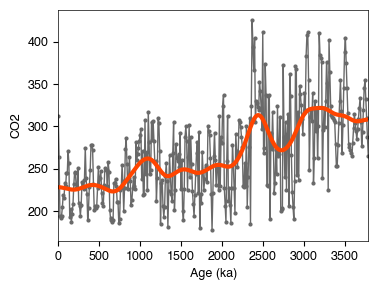

In [ ]:
######## Make the null hypothesis "truth" CO2 dataset
# Set a threshold to remove really low (unrealistic) alkenone and paleosol proxy values.
# Using 160 here bc min CO2 from the 800 ka traditional ice core record is 173 ppm.
lowThres = 160
# Set the cutoff point in time to find and compile proxy CO2 data (in ka)
timeCut = 3800
# first load 800 ka record of traditional ice core CO2
co2 = pd.read_csv("externalData/antarctica2015co2composite-noaa.txt",sep='\t')
co2age = co2['age_gas_calBP'].to_numpy()/1000
co2ppm = co2['co2_ppm'].to_numpy()
# then load boron data - from paleo-co2.org compilation
bdata = pd.read_csv("externalData/boron_co2.csv").sort_values(by='age')
# clip to timeCut value
bdataPlio = bdata.loc[bdata['age']<timeCut].reset_index(drop=True)
ageBoron = bdataPlio["age"].to_numpy()
co2Boron = bdataPlio["co2"].to_numpy()
# load paleosol co2 data - from paleo-co2.org compilation
pdata = pd.read_csv("externalData/paleosol_co2.csv").sort_values(by='age')
# remove data points below threshold value
pdata = pdata.loc[pdata["co2"]>lowThres].reset_index(drop=True)
agePaleo = pdata["age"].to_numpy()
co2Paleo = pdata["co2"].to_numpy()
# load alkenone co2 data - from paleo-co2.org compilation
alkCO2 = pd.read_csv("externalData/alkenone_co2.csv")
# clip and remove data points below threshold value
alkCO2 = alkCO2.loc[(alkCO2['age']<timeCut) & (alkCO2['co2']>lowThres)].reset_index(drop=True)
ageAlk = alkCO2["age"].to_numpy()
co2Alk = alkCO2["co2"].to_numpy()
# make a composite CO2 record using ice for < 800 ka then other proxies beyond
# boron
bages = ageBoron[ageBoron > co2age.max()]
bdats = co2Boron[ageBoron > co2age.max()]
# alkenone
aages = ageAlk[ageAlk > co2age.max()]
adats = co2Alk[ageAlk > co2age.max()]
# paleosol is only 1-3 Ma so doesn't need clipping
# concatenate together
compCO2age = np.concatenate((co2age,bages,agePaleo,aages))
compCO2 = np.concatenate((co2ppm,bdats,co2Paleo,adats))
indices = np.argsort(compCO2age)
compCO2age = compCO2age[indices]
compCO2 = compCO2[indices]
# resample the dataset to an even time step to avoid aliasing during forward modeling
# let's do 10 ka
tstep = 10
CO2dAge = np.arange(0,np.max(compCO2age),tstep)
CO2dVal = np.interp(CO2dAge,compCO2age,compCO2)
# also create a long-term gaussian smooth to highlight the trend
CO2Smooth = gaussian_filter1d(CO2dVal,sigma=10)

# sanity check plot
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(1, 1, 1)
ax.plot(CO2dAge,CO2dVal,marker='o',markersize=2,linewidth=1,color="dimgray")
ax.plot(CO2dAge,CO2Smooth,color="orangered",linewidth=3)
ax.set_xlim(CO2dAge.min(),CO2dAge.max())
ax.set_xlabel("Age (ka)")
ax.set_ylabel("CO2")
ax.invert_xaxis

In [ ]:
######### TIME AVERAGING 
# apply the time averaging function
CO2sim = iceTimeAvg(ice.Age, ice.AgeErrA, 400, CO2dAge,CO2dVal,1000)

In [ ]:
# uncomment to double check for nans - shouldn't be any
# nanAmount = np.count_nonzero(np.isnan(CO2sim))
# print(nanAmount)
# y_indices, x_indices = np.where(np.isnan(CO2sim))
# print("Row indices:", y_indices)
# print("Col indices:", x_indices) 

In [ ]:
###### MIXING
# compute middle depth
dmid = ice[['TopDepth', 'BottomDepth']].mean(axis=1)
# mix co2, use 10 cm as the dstep (mean sample width)
dstep = 0.1
# set mixing depth
md = 0.7
z, zp, co2mix, co2mixInt = mixIce(dmid,dstep,CO2sim,md)

Text(0, 0.5, 'CO2')

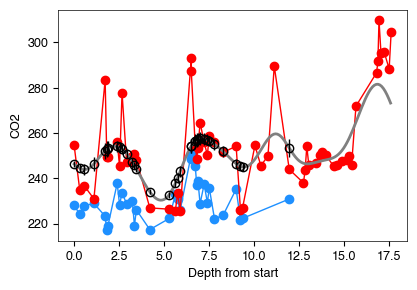

In [6]:
# sanity check plot to see the convolution results
co2pres = (~np.isnan(ice.CO2m)) & (ice.NotPristine == 0)
fig = plt.figure(figsize=(4.5,3))
ax = fig.add_subplot(1, 1, 1)
ax.plot(z[co2pres],ice.CO2m[co2pres],color="dodgerblue",marker='o')
ax.plot(z,np.mean(CO2sim,1),color="red",marker='o')
ax.plot(zp,np.mean(co2mix,1),color="gray",linewidth=2)
ax.errorbar(z[co2pres],np.mean(co2mixInt[co2pres,:],1),yerr=np.std(co2mixInt[co2pres,:],1),color="black",
            marker='o',markerfacecolor="None",markeredgecolor="black",linestyle="None")
ax.set_xlabel("Depth from start")
ax.set_ylabel("CO2")

In [ ]:
######### RESPIRATION CORRECTION
# assumes organic/metabolic end member is -30 +/- 0.5 in accordance with the paper.
# first find non-pristine samples that need correction
dCpres = (~np.isnan(ice.d13C)) & (ice.NotPristine == 1)
# OPTION 1: take a straight average of the two methods used for measurements.
# co2m = ice.loc[dCpres,['CO2m','CO2dC']].mean(axis=1).to_numpy()
# OPTION 2: only use CO2m
# co2m = ice.CO2m[dCpres].to_numpy()
# OPTION 3: only use CO2dC (not available for all samples!)
# co2m = ice.CO2dC[dCpres].to_numpy()
# OPTION 4 (CHOICE MADE IN PAPER): use CO2dC where present and CO2m otherwise
co2m = ice.CO2m[dCpres]
co2m = np.where(~np.isnan(ice.CO2dC[dCpres]), ice.CO2dC[dCpres], ice.CO2m[dCpres])
co2me = ice.CO2mErr[dCpres].to_numpy()

# get d13C
d13cmeas = ice.d13C[dCpres].to_numpy()
d13cmeas = d13cmeas[:,np.newaxis]
# number of simulations
N = 1000
# length of time series
M = len(co2m)
# endmember atmosphere d13C
d13catm = np.random.normal(-6.5, 0.25,size=(M,N))
# endmember organic d13C
d13cOC = np.random.normal(-30, .5,size=(M,N))

#isotope unmixing
CO2meas = np.random.normal(co2m,co2me,size=(N,M)).T
CO2corr = CO2meas * (d13cOC - d13cmeas) / (d13cOC - d13catm)

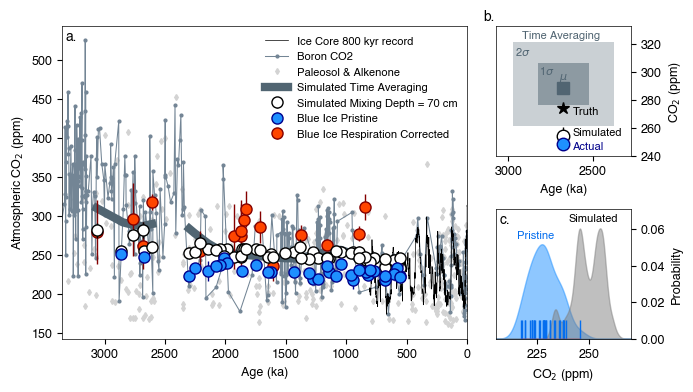

In [ ]:
################# MAIN PLOT
# find data where CO2 measurements are present
co2pres = ~np.isnan(ice.CO2m)
ms = 8
# sort time averaged data
SortIndex = np.argsort(ice.Age)
AgeSort = ice.Age[SortIndex].to_numpy()
CO2simSort = CO2sim[SortIndex,:]
# start figure
fig = plt.figure(figsize=(7,4))
gs = GridSpec(2, 2, width_ratios=[3, 1], figure=fig)
############ panel 1
ax0 = fig.add_subplot(gs[:, 0])
ax0.plot(co2age,co2ppm,color="black",linewidth=0.5,label="Ice Core 800 kyr record",zorder=3)
ax0.plot(ageBoron,co2Boron,color="xkcd:steel",linewidth=.75,marker='o',markersize=2, label="Boron CO2",zorder=2)
ax0.plot(agePaleo,co2Paleo,color="lightgray",linewidth=.75,marker='d',markersize=3, linestyle="None",zorder=1,label="Paleosol & Alkenone")
ax0.plot(ageAlk,co2Alk,color="lightgray",linewidth=.75,marker='d',markersize=3, linestyle="None",zorder=1)
ax0.plot(AgeSort[AgeSort < 2400],np.mean(CO2simSort[AgeSort < 2400],1),linewidth=6, color="xkcd:slate",zorder=4,label="Simulated Time Averaging")
ax0.plot(AgeSort[AgeSort > 2400],np.mean(CO2simSort[AgeSort > 2400],1),linewidth=6, color="xkcd:slate",zorder=4)
ax0.errorbar(ice.Age[co2pres],np.mean(co2mixInt[co2pres,:],1),yerr=np.std(co2mixInt[co2pres,:],1)*2,color="black",marker='o',linestyle='None',
        markeredgecolor="black",markerfacecolor="white",markersize=ms,label=f"Simulated Mixing Depth = {md*100:.0f} cm",zorder=6)
# plot pristine co2 samples
prist = ice.NotPristine == 0
co2p = ice.CO2m[prist]
co2p = np.where(~np.isnan(ice.CO2dC[prist]), ice.CO2dC[prist], ice.CO2m[prist])
ax0.errorbar(ice.Age[prist],co2p,yerr=ice.CO2mErr[prist]*2,markerfacecolor="dodgerblue",linestyle="None",
        markeredgecolor="darkblue",marker='o',markersize=ms, color="darkblue",label="Blue Ice Pristine",zorder=10)
ax0.errorbar(ice.Age[dCpres],np.mean(CO2corr,1),yerr=np.std(CO2corr,1)*2,color="xkcd:dark red",marker='o',linestyle='None',
        markeredgecolor="xkcd:dark red",markerfacecolor="orangered",markersize=ms,label="Blue Ice Respiration Corrected",zorder=5)
ax0.set_xlabel("Age (ka)")
ax0.set_ylabel("Atmospheric CO$_2$ (ppm)")
ax0.legend(loc='upper right',frameon=False, fontsize=8)
ax0.set_xlim(0,3350)
ax0.text(3325,525,"a.",fontsize=10)
ax0.invert_xaxis()
############ panel upper right - pliocene averaging
ax1 = fig.add_subplot(gs[0, 1])
plioIDX1 = 21
plioIDX2 = 55
ax1.plot(ice.Age[plioIDX1],np.mean(CO2Smooth[(CO2dAge > 2665) & (CO2dAge < 2675)]),marker='*',markersize=ms+1,color="black")
xStart = ice.Age[plioIDX1] - ice.AgeErrA[plioIDX1]
yStart = np.mean(CO2simSort[plioIDX2,:])-np.std(CO2simSort[plioIDX2,:])*2
rWidth = ice.AgeErrA[plioIDX1]*2
rHeight = np.std(CO2simSort[plioIDX2,:])*4
rect1 = patches.Rectangle((xStart, yStart), rWidth, rHeight, linewidth=2, edgecolor="None", facecolor="xkcd:slate", alpha=0.3, zorder=0)
rect2 = patches.Rectangle((xStart + ice.AgeErrA[plioIDX1]/2, yStart+np.std(CO2simSort[plioIDX2,:])), rWidth/2, rHeight/2, linewidth=2, 
                          edgecolor="None", facecolor="xkcd:slate", alpha=0.5, zorder=0)
ax1.add_patch(rect1)
ax1.add_patch(rect2)
ax1.plot(ice.Age[plioIDX1],np.mean(CO2simSort[54,:]),marker='s',markersize=ms+1,color="xkcd:slate")
ax1.errorbar(ice.Age[plioIDX1],np.mean(co2mixInt[plioIDX1,:]), yerr=np.std(co2mixInt[plioIDX1,:])*2, marker='o',markersize=ms+1,
             color="black",markerfacecolor="white")
ax1.errorbar(ice.Age[plioIDX1],ice.CO2m[plioIDX1], yerr=ice.CO2mErr[plioIDX1]*2, marker='o',markersize=ms+1,
             color="darkblue",markerfacecolor="dodgerblue")
ax1.text(2920,324,"Time Averaging",color="xkcd:slate",fontsize=8)
ax1.text(2960,312,"2$\sigma$",color="xkcd:slate",fontsize=8)
ax1.text(2820,298,"1$\sigma$",color="xkcd:slate",fontsize=8)
ax1.text(2700,295,"$\mu$",color="xkcd:slate",fontsize=8)
ax1.text(2620,270,"Truth", fontsize=8)
ax1.text(2620,255,"Simulated", fontsize=8)
ax1.text(2620,245,"Actual",color="darkblue", fontsize=8)
ax1.set_xlim(ice.Age[plioIDX1]-400,ice.Age[plioIDX1]+400)
ax1.set_ylim(240,333)
ax1.yaxis.tick_right()
ax1.yaxis.set_label_position("right")
ax1.set_xlabel("Age (ka)")
ax1.set_ylabel("CO$_2$ (ppm)")
ax1.text(3150,337,"b.",fontsize=10)
ax1.invert_xaxis()
############## panel lower right - histogram
ax2 = fig.add_subplot(gs[1, 1])
agep = ice.Age[prist]
pleistoDats = co2p[(agep < 2500) & (~np.isnan(co2p))]
kdeDats = gaussian_kde(pleistoDats)
kdeSims = gaussian_kde(co2mixInt[prist & co2pres & (ice.Age < 2500),:].flatten())
ageCorrs = ice.Age[dCpres]
kdeRes = gaussian_kde(CO2corr[ageCorrs < 2500,:].flatten())
xtar = np.linspace(205,280,400)
densDats = kdeDats.evaluate(xtar)
densSims = kdeSims.evaluate(xtar)
ax2.fill_between(xtar,densDats, color="dodgerblue", alpha=0.5)
ax2.fill_between(xtar,densSims, color="gray", alpha=0.5)
ax2.stem(pleistoDats,np.tile(0.01,len(pleistoDats)),linefmt="xkcd:cerulean blue",markerfmt="None")
ax2.text(215,0.055,"Pristine", color="xkcd:cerulean blue", fontsize=8)
ax2.text(240,0.064,"Simulated", fontsize=8)
ax2.set_ylim(0,0.071)
ax2.set_xlim(205,270)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set_ylabel("Probability")
ax2.set_xlabel("CO$_2$ (ppm)")
ax2.text(207,0.063,"c.",fontsize=10)

fig.tight_layout()
# print to pdf
fig.savefig("outputFigures/CO2Simulations.pdf", bbox_inches="tight")

In [ ]:
####### COMPARE PLEISTOCENE DATA, ACTUAL AND SIMULATED
# compute probability of overlap for pristine Pleistocene ice and simulated values based on kde
# Take the element-wise minimum of the two curves
overlap_pdf = np.minimum(densSims, densDats)
# Integrate the minimum curve to get the overlapping area
overlap_area = simpson(overlap_pdf, x=xtar)
# calculate mean of simulations and data
simPmean = np.mean(co2mixInt[prist & co2pres & (ice.Age < 2500),:].flatten())

print(f"Probability of overlap: {overlap_area*100:.0f}%")

#also compute mean
simPleistoMean = np.mean(co2mixInt[prist & co2pres & (ice.Age < 2500),:].flatten())
PleistoMean = np.mean(pleistoDats)

print(f"Pleistocene Data Mean: {PleistoMean:.0f} ppm")
print(f"Simulated Pleistocene Mean: {simPleistoMean:.0f} ppm")

Probability of overlap: 18%
Pleistocene Data Mean: 228 ppm
Simulated Pleistocene Mean: 249 ppm


In [ ]:
##### COMPARE STATISTICS FOR SIMULATED AND ACTUAL CO2
# first the variance. 70 cm mixing produces the best match when we consider just the Pleistocene data
# the Pliocene datapoints are higher overall so they raise the variance
idx = prist & co2pres & (ice.Age < 2500)
icevar = np.var(pleistoDats)
simvar = np.var(np.mean(co2mixInt[idx,:],1))
print(f"Data Variance: {icevar:.0f}")
print(f"Simulated Variance: {simvar:.0f}")
# RMSE
rmse = np.sqrt(np.mean(np.square(ice.CO2m[idx] - np.mean(co2mixInt[idx,:],1))))
print(f"RMSE: {rmse:.0f} ppm")
# correlation - note that it is not high bc data don't have much of a trend.
corrmatrix = np.corrcoef(ice.CO2m[idx],np.mean(co2mixInt[idx,:],1))
print(f"Correlation between data and simulation: {corrmatrix[0, 1]:.2f}")

Data Variance: 46
Simulated Variance: 46
RMSE: 22 ppm
Correlation between data and simulation: 0.44


In [ ]:
######### COMPARE PLIOCENE CO2
# null
print(f"Pliocene Null CO2: {np.mean(CO2dVal[(CO2dAge > 2500) & (CO2dAge < 3100)]):.0f} ± {np.std(CO2dVal[(CO2dAge > 2500) & (CO2dAge < 3100)])*2:.0f}")

# simulated time averaged co2
print(f"Pliocene Simulated Time Averaged CO2: {np.mean(CO2simSort[AgeSort > 2500,:]):.0f} ± {np.std(CO2simSort[AgeSort > 2500,:])*2:.0f}")

# simulated mixed co2 - respired
agec = ice.Age[co2pres & dCpres]
co2sim = co2mixInt[co2pres & dCpres,:]
print(f"Pliocene Simulated Mixed CO2 (Respired): {np.mean(co2sim[agec > 2500,:]):.0f} ± {np.std(co2sim[agec > 2500,:])*2:.0f}")

# respiration corrected
agecIso = ice.Age[dCpres]
print(f"Pliocene Respiration-corrected CO2: {np.mean(CO2corr[agecIso > 2500,:]):.0f} ± {np.std(CO2corr[agecIso > 2500,:])*2:.0f}")

# simulated mixed pristine
agecP = ice.Age[co2pres & prist]
co2simP = co2mixInt[co2pres & prist,:]
print(f"Pliocene Simulated Mixed CO2 (Pristine): {np.mean(co2simP[agecP > 2500,:]):.0f} ± {np.std(co2simP[agecP > 2500,:])*2:.0f}")

# pliocene pristine CO2 actual data
co2E = ice.CO2mErr[co2pres & prist]
print(f"Pliocene Actual CO2 (Pristine): {np.mean(co2p[agep > 2500]):.0f} ± {0.5*np.sqrt(np.sum((co2E[agecP > 2500])**2))*2:.0f}")

Pliocene Null CO2: 290 ± 116
Pliocene Simulated Time Averaged CO2: 294 ± 31
Pliocene Simulated Mixed CO2 (Respired): 274 ± 20
Pliocene Respiration-corrected CO2: 289 ± 54
Pliocene Simulated Mixed CO2 (Pristine): 254 ± 6
Pliocene Actual CO2 (Pristine): 249 ± 1


In [ ]:
###### LOOK AT THE TREND IN CO2 IN THE PLEISTOCENE
tCut = 2500
idx = prist & co2pres & (ice.Age < tCut)
#pleistoDats = ice.CO2m[idx]
pleistoTime = np.mean(CO2sim[idx,:],axis=1)
pleistoSim = np.mean(co2mixInt[idx,:],axis=1)
pleistoAge = ice.Age[idx]/1000
idx2 = (CO2dAge < tCut) & (CO2dAge > 500)
nullAge = CO2dAge[idx2]/1000
nullCO2 = CO2dVal[idx2]

datout = linregress(pleistoAge,pleistoDats)
tout = linregress(pleistoAge,pleistoTime)
simout = linregress(pleistoAge,pleistoSim)
nullout = linregress(nullAge,nullCO2)

print(f"Data Slope: {datout.slope:.1f} ± {datout.stderr*2:.1f}")
print(f"Data p-value: {datout.pvalue:.3f}")
print(f"Data Correlation: {datout.rvalue:.2f}")

print(f"Simulated Slope: {simout.slope:.1f} ± {simout.stderr*2:.1f}")
print(f"Simulated p-value: {simout.pvalue:.3f}")
print(f"Simulated Correlation: {simout.rvalue:.2f}")

print(f"Time Avg Slope: {tout.slope:.1f} ± {simout.stderr*2:.1f}")
print(f"Time Avg p-value: {tout.pvalue:.3f}")
print(f"Time Avg Correlation: {tout.rvalue:.2f}")

print(f"Null Avg Slope: {nullout.slope:.1f} ± {simout.stderr*2:.1f}")
print(f"Null Avg p-value: {nullout.pvalue:.3f}")
print(f"Null Avg Correlation: {nullout.rvalue:.2f}")

Data Slope: 6.0 ± 3.9
Data p-value: 0.004
Data Correlation: 0.49
Simulated Slope: 9.0 ± 3.0
Simulated p-value: 0.000
Simulated Correlation: 0.74
Time Avg Slope: 21.3 ± 3.0
Time Avg p-value: 0.000
Time Avg Correlation: 0.83
Null Avg Slope: 30.0 ± 3.0
Null Avg p-value: 0.000
Null Avg Correlation: 0.39
